<a href="https://colab.research.google.com/github/bea00518/ProjetoFinalAME/blob/main/Notebook_Entregavel2_FireMLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Incêndio - MLP
Notebook para o Entregável 2.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fire_data.csv to fire_data.csv


## Carregar Dataset

In [ ]:

df = pd.read_csv('fire_data.csv')
df.head()


,eco2,humidity,pressure,raw_ethanol,raw_h2,temperature,timestamp,fire_alarm
0,400,70.11423,1006.06000,3166,499,32.72419,9,0
1,409,70.06827,1006.04999,3181,431,32.69844,11,0
2,400,70.03365,1006.01001,3197,436,32.72800,12,0
3,400,70.01781,1006.03998,3200,435,32.76405,13,0
4,400,69.98224,1006.09003,3212,429,32.77359,14,0


In [ ]:

print('Formato:', df.shape)
print(df.info())
print(df.isnull().sum())


Formato: (6121, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6121 entries, 0 to 6120
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   eco2         6121 non-null   int64  
 1   humidity     6121 non-null   float64
 2   pressure     6121 non-null   float64
 3   raw_ethanol  6121 non-null   int64  
 4   raw_h2       6121 non-null   int64  
 5   temperature  6121 non-null   float64
 6   timestamp    6121 non-null   int64  
 7   fire_alarm   6121 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 382.7 KB
None
eco2           0
humidity       0
pressure       0
raw_ethanol    0
raw_h2         0
temperature    0
timestamp      0
fire_alarm     0
dtype: int64


fire_alarm
0    3263
1    2858
Name: count, dtype: int64


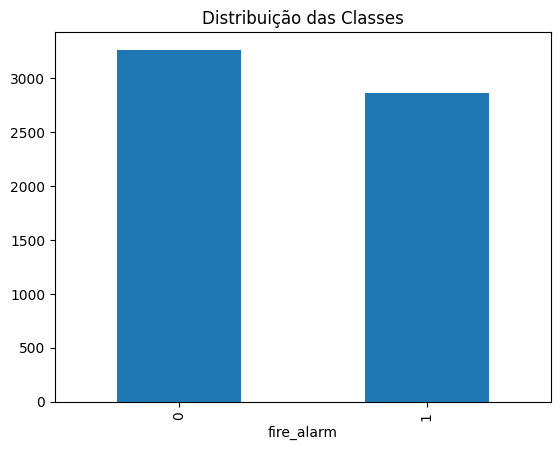

In [ ]:

print(df['fire_alarm'].value_counts())

df['fire_alarm'].value_counts().plot(kind='bar')
plt.title('Distribuição das Classes')
plt.show()


## Pré-processamento

In [ ]:

#normalização, dados em escalas diferentes
X = df.drop('fire_alarm', axis=1)
y = df['fire_alarm']

scaler = MinMaxScaler()
X = scaler.fit_transform(X)


In [ ]:

#divisão do conjunto de dados em treino, validação e teste
#70% dos dados são usados para treinar o modelo
#15% são usados para validação
#15% são usados para teste (avaliação final do desempenho)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)


(4284, 7)
(918, 7)
(919, 7)


## Modelo MLP

In [ ]:

#criação do modelo de Rede Neural utilizando Keras
#a rede possui:
# - Camada de entrada + camada oculta com 16 neurônios e função ReLU
# - Segunda camada oculta com 8 neurônios e função ReLU
# - Camada de saída com 1 neurônio e função Sigmoid (classificação binária)
# O modelo é compilado com:
# - Otimizador Adam
# - Função de perda Binary Crossentropy
# - Métrica de avaliação Accuracy

# O total de parâmetros treináveis é 273, indica um modelo leve,
# com baixa complexidade computacional e menor risco de overfitting,
# adequado para o conjunto de dados utilizado.

model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

#treinamento ocorre por 50 épocas, com lotes de 32 amostras.

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)


Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8730 - loss: 0.5690 - val_accuracy: 0.9183 - val_loss: 0.4338
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9132 - loss: 0.3146 - val_accuracy: 0.9270 - val_loss: 0.2411
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9164 - loss: 0.2202 - val_accuracy: 0.9172 - val_loss: 0.2086
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9176 - loss: 0.2031 - val_accuracy: 0.9314 - val_loss: 0.2013
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9199 - loss: 0.1969 - val_accuracy: 0.9281 - val_loss: 0.1953
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9227 - loss: 0.1924 - val_accuracy: 0.9281 - val_loss: 0.1930
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9218 - loss: 0.1892 - val_accuracy: 0.9336 - val_loss: 0.1893
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9246 - loss: 0.1857 - val_accuracy: 0.

## Gráfico de Loss

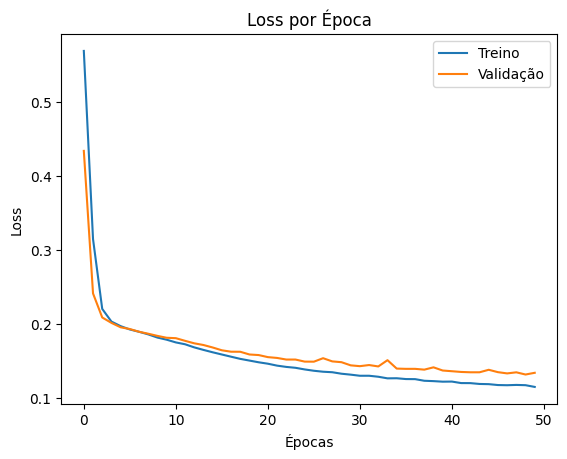

In [ ]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss por Época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(['Treino','Validação'])
plt.show()


## Gráfico de Accuracy

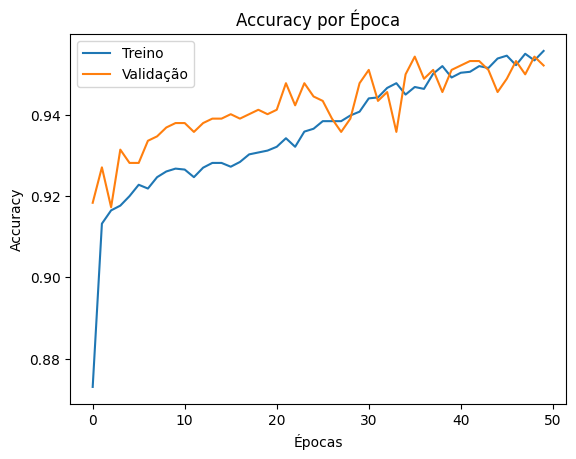

In [ ]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy por Época')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend(['Treino','Validação'])
plt.show()


## Avaliação

In [ ]:

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy :', acc)
print('Precision:', prec)
print('Recall   :', rec)
print('F1-score :', f1)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy : 0.9619151251360174
Precision: 0.9716312056737588
Recall   : 0.9470046082949308
F1-score : 0.9591598599766628


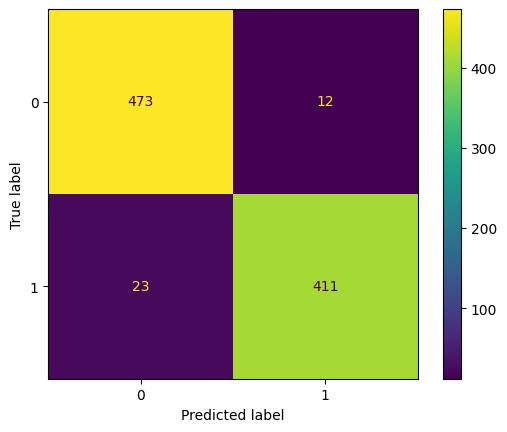

In [ ]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()
